In [1]:
import os
os.chdir("/Users/nataschajademinnitt/Documents/5_data/disease_outbreak_news_data")

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("data/don_registry.db")
df_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(df_tables)



          name
0          don
1          iso
2          icd
3  icd_aliases
4    outbreaks
5  iso_aliases


In [79]:
df = pd.read_sql("SELECT * FROM outbreaks", conn)
df.head()

,recorded,id_outbreak,year,iso_code,icd_code,don
0,2026-06-01 15:39:49,2026-DON603:COD:1D60.0Z,2026,COD,1D60.0Z,2026-DON603
1,2026-06-01 15:39:49,2026-DON603:COG:1D60.0Z,2026,COG,1D60.0Z,2026-DON603
2,2026-06-01 15:39:49,2026-DON602:UGA:1D60.0Z,2026,UGA,1D60.0Z,2026-DON602
3,2026-06-01 15:39:49,2026-DON602:COD:1D60.0Z,2026,COD,1D60.0Z,2026-DON602
4,2026-06-01 15:39:49,2026-DON602:COG:1D60.0Z,2026,COG,1D60.0Z,2026-DON602


In [84]:
iso_check = df.iso_code.isna().sum()
icd_check = df.icd_code.isna().sum()
print("iso is na = ", iso_check, "icd is na = ", icd_check)

iso is na =  613 icd is na =  203


In [103]:
# Titles where no ISO code was matched
iso_no_match = pd.read_sql("""
    SELECT DISTINCT d.title
    FROM outbreaks o
    JOIN don d ON d.identifier = o.don
    WHERE o.iso_code IS NULL
    ORDER BY d.title
""", conn)

pd.set_option("display.max_colwidth", None)
iso_no_match.to_csv("exploration/iso_no_match.csv", index=False)

In [102]:
# Titles where no ICD code was matched
icd_no_match = pd.read_sql("""
    SELECT DISTINCT d.title
    FROM outbreaks o
    JOIN don d ON d.identifier = o.don
    WHERE o.icd_code IS NULL
    ORDER BY d.title
""", conn)

icd_no_match.to_csv("exploration/icd_no_match.csv", index=False)

In [4]:
df = pd.read_sql("SELECT * FROM don LIMIT 100", conn)
df.head()

,recorded,identifier,url,publication,title,content,scrape
0,2026-05-27 12:14:47,2026-DON603,https://www.who.int/emergencies/disease-outbre...,2026-05-21,Ebola disease caused by Bundibugyo virus – Dem...,"On 15 May 2026, the Ministry of Public Health,...",1
1,2026-05-27 12:14:47,2026-DON602,https://www.who.int/emergencies/disease-outbre...,2026-05-16,"Ebola disease caused by Bundibugyo virus, Demo...","On 5 May 2026, the World Health Organization (...",1
2,2026-05-27 12:14:47,2026-DON601,https://www.who.int/emergencies/disease-outbre...,2026-05-13,Hantavirus cluster linked to cruise ship trave...,This is the third Disease Outbreak News report...,1
3,2026-05-27 12:14:47,2026-DON600,https://www.who.int/emergencies/disease-outbre...,2026-05-08,Hantavirus cluster linked to cruise ship trave...,"On 2 May 2026, a cluster of passengers with se...",1
4,2026-05-27 12:14:47,2026-DON599,https://www.who.int/emergencies/disease-outbre...,2026-05-04,Hantavirus cluster linked to cruise ship trave...,"On 2 May 2026, a cluster of passengers with se...",1


In [15]:
df = pd.read_sql("SELECT * FROM don", conn)
df["recorded"] = pd.to_datetime(df["recorded"])
df["publication"] = pd.to_datetime(df["publication"])
df.dtypes

recorded       datetime64[us]
identifier                str
url                       str
publication    datetime64[us]
title                     str
content                   str
scrape                  int64
dtype: object

<Axes: >

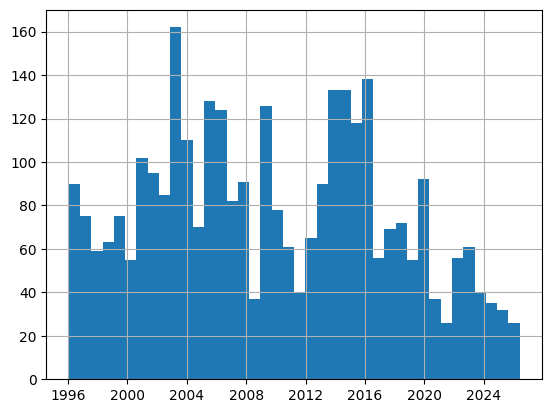

In [20]:
df.publication.hist(bins=40)

In [26]:
for title in df.title.sample(50):
    print(title)

2001 - Anthrax in the United States - Update 10
Measles - Somalia
Hepatitis E - Sudan
1998 - Plague in Uganda
Yellow fever – Nigeria
Meningococcal disease: situation in the African Meningitis Belt
Bloody diarrhoea - Liberia
Yellow fever - Côte d'Ivoire
Yellow fever in Chad
Cholera – United Republic of Tanzania
Ebola virus disease – Democratic Republic of the Congo
Meningococcal disease in Burkina Faso - update
Ebola virus disease – Democratic Republic of the Congo
Ebola virus disease – Democratic Republic of the Congo
Yellow fever – Nigeria
Marburg virus disease - Equatorial Guinea
Avian influenza - situation in China, Hong Kong Special Administrative Region (Hong Kong, SAR) - update
Pandemic (H1N1) 2009 - update 56
Poliomyelitis in Indonesia - update 4
Avian influenza – situation in Indonesia – update 30
Cholera – Global situation
Cholera – Mozambique
Novel Coronavirus – China
Influenza A(H1N1) - update 31
Circulating vaccine-derived poliovirus type 2 (cVDPV2) – Yemen
Chikungunya – Su

In [12]:
df = pd.read_sql("PRAGMA table_info(don)", conn)
print(df)

   cid         name       type  notnull         dflt_value  pk
0    0     recorded  TIMESTAMP        0  CURRENT_TIMESTAMP   0
1    1   identifier       TEXT        0                NaN   1
2    2          url       TEXT        1                NaN   0
3    3  publication       DATE        1                NaN   0
4    4        title       TEXT        1                NaN   0
5    5      content       TEXT        0                NaN   0
6    6       scrape    INTEGER        0                  0   0


In [31]:
import re

def add_iso_columns(df, conn):
    iso = pd.read_sql("SELECT code, name_en FROM iso", conn)
    aliases = pd.read_sql("SELECT iso_code, alias FROM iso_aliases", conn)

    # Combine all (name, code) pairs; sort longest first to prefer specific matches
    lookup = (
        list(zip(iso["name_en"], iso["code"])) +
        list(zip(aliases["alias"], aliases["iso_code"]))
    )
    lookup.sort(key=lambda x: len(x[0]), reverse=True)

    def find_iso(title):
        codes = set()
        for name, code in lookup:
            if re.search(r"(?<!\w)" + re.escape(name) + r"(?!\w)", title, re.IGNORECASE):
                codes.add(code)
        return codes

    matches = df["title"].apply(find_iso)
    df["iso_included"] = matches.apply(lambda x: 1 if x else 0)
    df["iso_count"] = matches.apply(len)
    df["iso_codes"] = matches.apply(lambda x: sorted(x) if x else [])
    return df

df = add_iso_columns(df, conn)
df[["title", "iso_included", "iso_count", "iso_codes"]].head(10)

,title,iso_included,iso_count,iso_codes
0,Ebola disease caused by Bundibugyo virus – Dem...,1,2,"[COD, COG]"
1,"Ebola disease caused by Bundibugyo virus, Demo...",1,3,"[COD, COG, UGA]"
2,Hantavirus cluster linked to cruise ship trave...,0,0,[]
3,Hantavirus cluster linked to cruise ship trave...,0,0,[]
4,Hantavirus cluster linked to cruise ship trave...,0,0,[]
5,Measles - Bangladesh,1,1,[BGD]
6,Avian Influenza A(H9N2) - Italy,1,1,[ITA]
7,International food safety event: Infant formul...,0,0,[]
8,Mpox: recombinant virus with genomic elements ...,0,0,[]
9,Nipah virus infection - Bangladesh,1,1,[BGD]


In [72]:
df[["title", "iso_included", "iso_count", "iso_codes"]].sample(100)

,title,iso_included,iso_count,iso_codes
2639,"2001 - Meningococcal disease, serogroup W135 -...",0,0,[]
116,Dengue - Bangladesh,1,1,[BGD]
1095,Influenza A (H3N2) virus - Madagascar,1,1,[MDG]
369,Dengue fever – Pakistan,1,1,[PAK]
405,Ebola virus disease – Democratic Republic of t...,1,2,"[COD, COG]"
...,...,...,...,...
2937,1998 - Cholera-like diarrhoeal disease in the ...,1,1,[COG]
827,Influenza A H5N6 virus – China,1,1,[CHN]
2736,2000 - Cholera in Afghanistan,1,1,[AFG]
2867,2000 - Meningococcal disease in Hungary,1,1,[HUN]


In [61]:
df.iso_count.value_counts()

iso_count
1    2095
0     634
2     373
3      37
4       3
Name: count, dtype: int64

In [62]:
check = df[df["iso_count"] < 1]
for title in check.title:
    print(title)

Hantavirus cluster linked to cruise ship travel, Multi-country
Hantavirus cluster linked to cruise ship travel, Multi-country
Hantavirus cluster linked to cruise ship travel, Multi-country
International food safety event: Infant formula and products containing arachidonic acid oil contaminated with cereulide toxin - Multi-country
Mpox: recombinant virus with genomic elements of clades Ib and IIb – Global situation
Middle East respiratory syndrome coronavirus - Global update
Seasonal influenza - Global situation
Broader transmission of mpox due to clade Ib MPXV – Global situation
Diphtheria - African Region (AFRO)
Chikungunya virus disease- Global situation
Cholera – Multi-country with a focus on countries experiencing current surges
COVID-19 - Global Situation
Yellow fever - Region of the Americas
Measles – Region of the Americas
Trends of acute respiratory infection, including human metapneumovirus, in the Northern Hemisphere
Oropouche virus disease - Region of the Americas
Avian Infl

In [78]:
check = df[df.title.str.contains("global", case=False)]
for title in check.title:
    print(title)

Mpox: recombinant virus with genomic elements of clades Ib and IIb – Global situation
Middle East respiratory syndrome coronavirus - Global update
Seasonal influenza - Global situation
Broader transmission of mpox due to clade Ib MPXV – Global situation
Chikungunya virus disease- Global situation
COVID-19 - Global Situation
Antimicrobial Resistance, Hypervirulent Klebsiella pneumoniae - Global situation
Dengue - Global situation
Dengue- Global situation
Cholera – Global situation
Cholera – Global situation
Circulating vaccine-derived poliovirus type 2 – Global update
Measles – Global situation
Influenza A (H1N1) virus - Global
Influenza A(H1N1) virus - Global
Influenza A (H1N1) virus - Global
Influenza A (H1N1) virus - Global
Influenza - Global
Avian influenza A(H5N1) - update 21:Global surveillance guidelines, Investigation of possible human-to-human transmission: data on second sister in family cluster in Viet Nam
Avian influenza A(H5N1) - update 20: Overview of the global situation:

In [32]:
def add_icd_columns(df, conn):
    icd = pd.read_sql("SELECT code, name_en FROM icd", conn)
    aliases = pd.read_sql("SELECT icd_code, alias FROM icd_aliases", conn)

    # Combine all (name, code) pairs; sort longest first to prefer specific matches
    lookup = (
        list(zip(icd["name_en"], icd["code"])) +
        list(zip(aliases["alias"], aliases["icd_code"]))
    )
    lookup.sort(key=lambda x: len(x[0]), reverse=True)

    def find_icd(title):
        codes = set()
        for name, code in lookup:
            if re.search(r"(?<!\w)" + re.escape(name) + r"(?!\w)", title, re.IGNORECASE):
                codes.add(code)
        return codes

    matches = df["title"].apply(find_icd)
    df["icd_included"] = matches.apply(lambda x: 1 if x else 0)
    df["icd_count"] = matches.apply(len)
    df["icd_codes"] = matches.apply(lambda x: sorted(x) if x else [])
    return df

df = add_icd_columns(df, conn)
df[["title", "icd_included", "icd_count", "icd_codes"]].head(10)

,title,icd_included,icd_count,icd_codes
0,Ebola disease caused by Bundibugyo virus – Dem...,1,2,"[1D60.0, 1D60.0Z]"
1,"Ebola disease caused by Bundibugyo virus, Demo...",1,2,"[1D60.0, 1D60.0Z]"
2,Hantavirus cluster linked to cruise ship trave...,0,0,[]
3,Hantavirus cluster linked to cruise ship trave...,0,0,[]
4,Hantavirus cluster linked to cruise ship trave...,0,0,[]
5,Measles - Bangladesh,1,1,[1F03]
6,Avian Influenza A(H9N2) - Italy,1,1,[1E31]
7,International food safety event: Infant formul...,0,0,[]
8,Mpox: recombinant virus with genomic elements ...,1,1,[1E71]
9,Nipah virus infection - Bangladesh,0,0,[]


In [53]:
icd_aliases[icd_aliases.alias.str.contains("malaria", case=False)]

,id,icd_code,alias
2520,2521,1C61.0,HIV disease clinical stage 1 associated with m...
2521,2522,1C61.1,HIV disease clinical stage 2 associated with m...
2522,2523,1C61.2,HIV disease clinical stage 3 associated with m...
2523,2524,1C61.Z,Human immunodeficiency virus disease associate...
2524,2525,1C61.Z,Human immunodeficiency virus disease associate...
...,...,...,...
5849,5850,1F42.Z,quartan malaria
5852,5853,1F42.Z,Plasmodium malariae malaria NOS
5853,5854,1F42.Z,quartan malarial
5854,5855,1F42.Z,malaria by plasmodium malariae


In [55]:
icd[icd.name_en.str.contains("malaria", case=False)]

,code,name_en
70,1C61,Human immunodeficiency virus disease associate...
71,1C62,Human immunodeficiency virus disease without m...
384,1C61.0,HIV disease clinical stage 1 associated with m...
385,1C61.1,HIV disease clinical stage 2 associated with m...
386,1C61.2,HIV disease clinical stage 3 associated with m...
387,1C61.3,HIV disease clinical stage 4 associated with m...
388,1C61.Z,Human immunodeficiency virus disease associate...
389,1C62.0,HIV disease clinical stage 1 without mention o...
390,1C62.1,HIV disease clinical stage 2 without mention o...
391,1C62.2,HIV disease clinical stage 3 without mention o...


In [38]:
df[["title", "icd_included", "icd_count", "icd_codes"]].sample(10)

,title,icd_included,icd_count,icd_codes
1304,Human infection with avian influenza A(H7N9) v...,1,1,[1E31]
2945,1998 - Influenza A(H5N1) in Hong Kong - Update 5,0,0,[]
1086,Meningococcal Meningitis - Burkina Faso,1,1,[1C1C.0]
2754,2000 - Legionnaires' disease in Australia,0,0,[]
2241,Avian influenza – situation in Thailand,1,1,[1E31]
270,Ebola virus disease – Guinea,1,1,[1D60.01]
3009,1997 - Meningococcal disease in Spain,1,2,"[1C1C, 1C1C.Z]"
1298,Human infection with avian influenza A(H7N9) v...,1,1,[1E31]
1833,Avian influenza - situation in Bangladesh,1,1,[1E31]
2079,Avian influenza – situation in Iraq - Update 2,1,1,[1E31]


In [42]:
df.icd_count.value_counts()

icd_count
1    2041
0     874
2     223
3       3
4       1
Name: count, dtype: int64

In [52]:
check = df[df["icd_count"] < 1]
for title in check.title:
    print(title)

Hantavirus cluster linked to cruise ship travel, Multi-country
Hantavirus cluster linked to cruise ship travel, Multi-country
Hantavirus cluster linked to cruise ship travel, Multi-country
International food safety event: Infant formula and products containing arachidonic acid oil contaminated with cereulide toxin - Multi-country
Nipah virus infection - Bangladesh
Nipah virus disease - India
Seasonal influenza - Global situation
Nipah virus infection - Bangladesh
Circulating vaccine-derived poliovirus type 1- Israel
Nipah Virus Infection - India
COVID-19 - Global Situation
Circulating vaccine-derived poliovirus type 2 (cVDPV2) - Papua New Guinea
Chikungunya - La Réunion and Mayotte
Cluster of community deaths in Basankusu, Equateur- Democratic Republic of the Congo
Trends of acute respiratory infection, including human metapneumovirus, in the Northern Hemisphere
Acute respiratory infections complicated by malaria (previously undiagnosed disease) - Democratic Republic of the Congo
Undia

In [ ]:
df = pd.read_sql("""
    SELECT
        d.identifier, d.publication, d.title,
        o.year, o.iso_code, o.icd_code,
        i.name_en  AS country,
        c.name_en  AS disease
    FROM outbreaks o
    JOIN don       d ON d.identifier = o.don
    LEFT JOIN iso  i ON i.code       = o.iso_code
    LEFT JOIN icd  c ON c.code       = o.icd_code
    WHERE d.is_outbreak = 1
""", conn)
